# Mountains vs Beaches ML Classification

This project aims to predict user preferences between mountains and beaches using Machine Learning techniques.

The workflow includes:
- data exploration
- preprocessing
- model training
- evaluation and comparison

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

sns.set(style="whitegrid")

## Data Loading

The dataset used in this project is publicly available on Kaggle:

https://www.kaggle.com/datasets/jahnavipaliwal/mountains-vs-beaches-preference

It contains user preferences between mountains and beaches along with demographic and behavioral features.

The dataset is loaded from a CSV file and prepared for further analysis.

In [ ]:
import os
import pandas as pd

if os.path.exists("data/mountains_vs_beaches_preferences.csv"):
    df = pd.read_csv("data/mountains_vs_beaches_preferences.csv")
else:
    df = pd.read_csv("/content/mountains_vs_beaches_preferences.csv")

df.head()

,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,male,71477,bachelor,9,skiing,2477,urban,175,267,summer,0,1,1
1,69,male,88740,master,1,swimming,4777,suburban,228,190,fall,0,1,0
2,46,female,46562,master,0,skiing,1469,urban,71,280,winter,0,0,1
3,32,non-binary,99044,high school,6,hiking,1482,rural,31,255,summer,1,0,1
4,60,female,106583,high school,5,sunbathing,516,suburban,23,151,winter,1,1,0


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the distribution of features and the target variable, as well as identify potential patterns and relationships.


In [ ]:
print("Dataset shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset shape: (52444, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52444 entries, 0 to 52443
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     52444 non-null  int64 
 1   Gender                  52444 non-null  object
 2   Income                  52444 non-null  int64 
 3   Education_Level         52444 non-null  object
 4   Travel_Frequency        52444 non-null  int64 
 5   Preferred_Activities    52444 non-null  object
 6   Vacation_Budget         52444 non-null  int64 
 7   Location                52444 non-null  object
 8   Proximity_to_Mountains  52444 non-null  int64 
 9   Proximity_to_Beaches    52444 non-null  int64 
 10  Favorite_Season         52444 non-null  object
 11  Pets                    52444 non-null  int64 
 12  Environmental_Concerns  52444 non-null  int64 
 13  Preference              52444 non-null  int64 
dtypes: int64(9), object(5)
memo

,Age,Income,Travel_Frequency,Vacation_Budget,Proximity_to_Mountains,Proximity_to_Beaches,Pets,Environmental_Concerns,Preference
count,52444.000000,52444.000000,52444.000000,52444.000000,52444.000000,52444.000000,52444.000000,52444.000000,52444.000000
mean,43.507360,70017.271280,4.489265,2741.799062,149.943502,149.888452,0.500858,0.498436,0.250706
std,14.985597,28847.560428,2.876130,1296.922423,86.548644,86.469248,0.500004,0.500002,0.433423
min,18.000000,20001.000000,0.000000,500.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,45048.250000,2.000000,1622.000000,75.000000,75.750000,0.000000,0.000000,0.000000
50%,43.000000,70167.000000,4.000000,2733.000000,150.000000,150.000000,1.000000,0.000000,0.000000
75%,56.000000,95108.500000,7.000000,3869.000000,225.000000,225.000000,1.000000,1.000000,1.000000
max,69.000000,119999.000000,9.000000,4999.000000,299.000000,299.000000,1.000000,1.000000,1.000000


### Target Distribution
The target distribution allows us to verify whether the dataset is balanced or not.

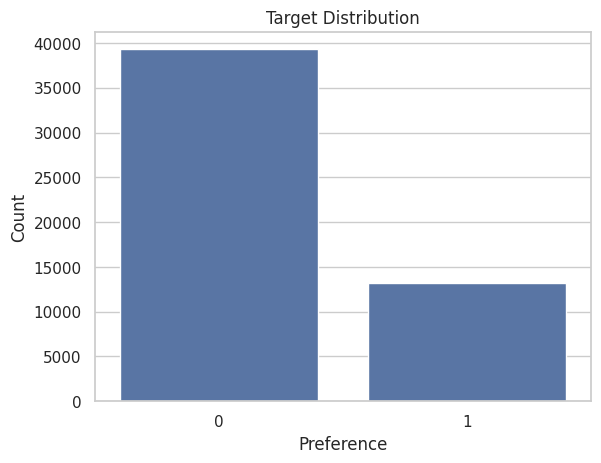

In [ ]:
sns.countplot(x=df["Preference"])
plt.title("Target Distribution")
plt.xlabel("Preference")
plt.ylabel("Count")
plt.show()

### Feature Distributions

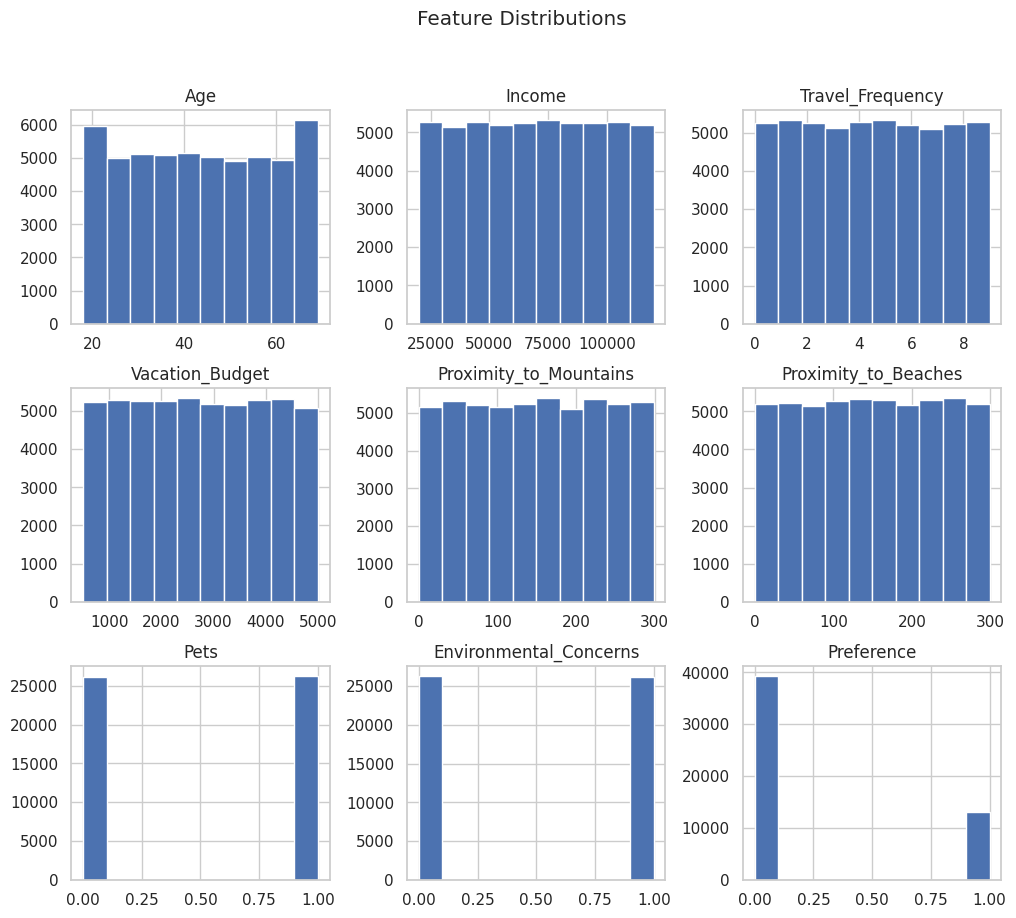

In [ ]:
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

### Correlation Analysis
The resulting heatmap highlights relationships between features and helps identify redundant or highly correlated variables.

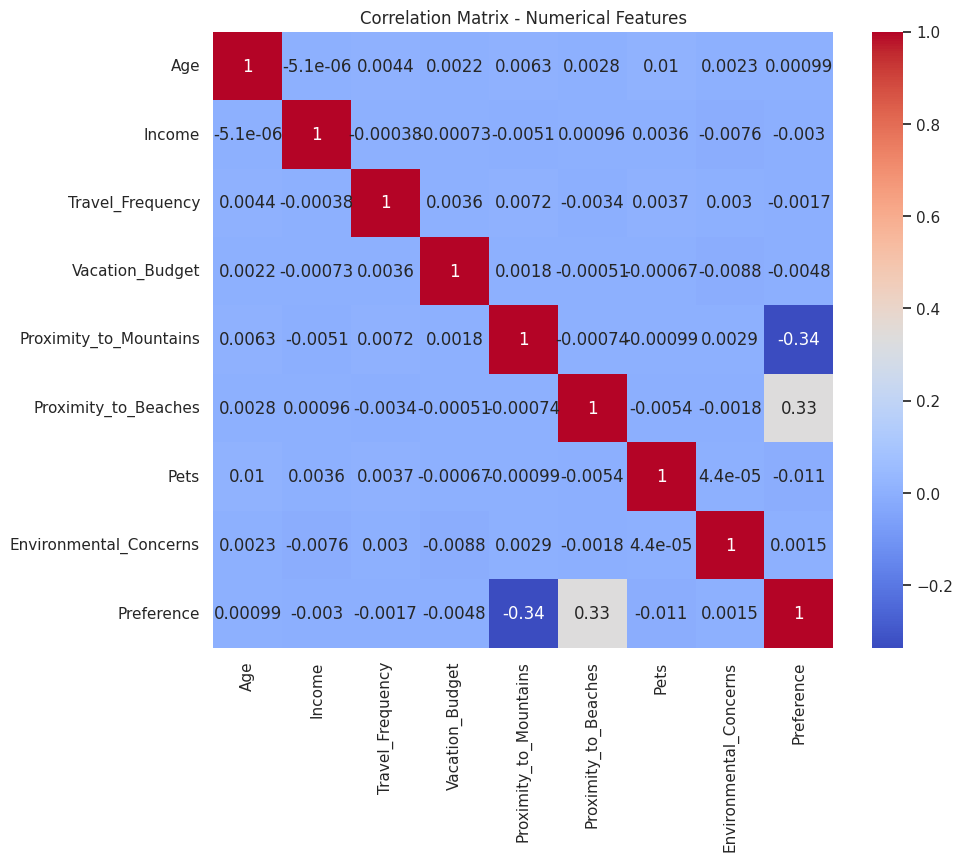

In [ ]:
# Correlation matrix only on numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - Numerical Features")
plt.show()

### Feature vs Target Analysis

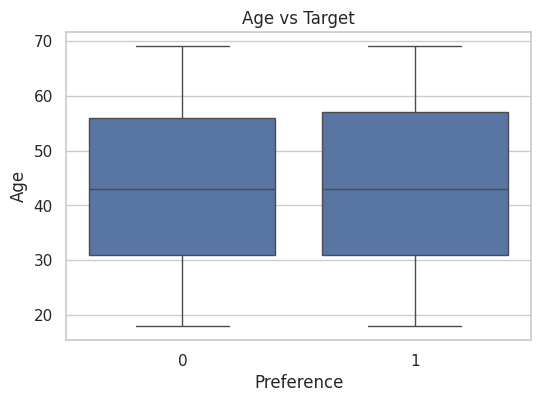

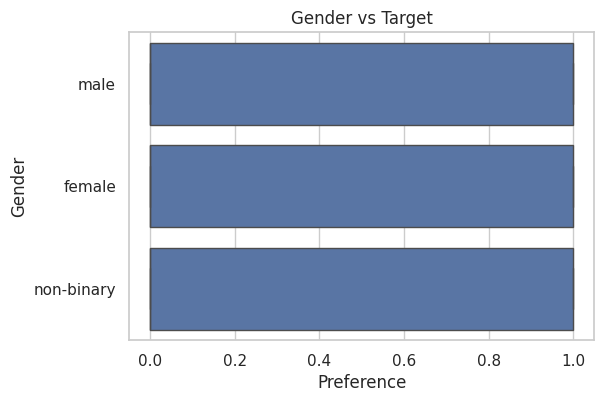

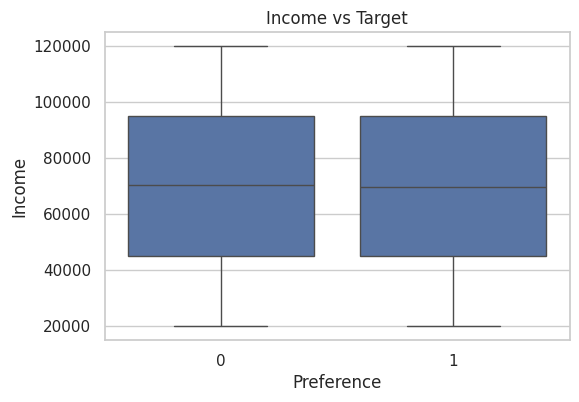

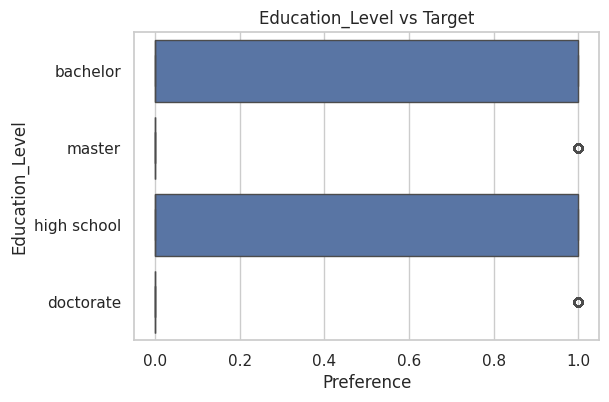

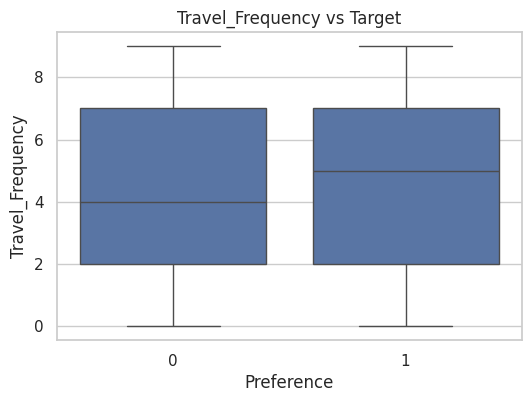

In [ ]:
features = df.drop("Preference", axis=1).columns

for col in features[:5]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df["Preference"], y=df[col])
    plt.title(f"{col} vs Target")
    plt.show()

### Missing Values

Age                       0
Gender                    0
Income                    0
Education_Level           0
Travel_Frequency          0
Preferred_Activities      0
Vacation_Budget           0
Location                  0
Proximity_to_Mountains    0
Proximity_to_Beaches      0
Favorite_Season           0
Pets                      0
Environmental_Concerns    0
Preference                0
dtype: int64


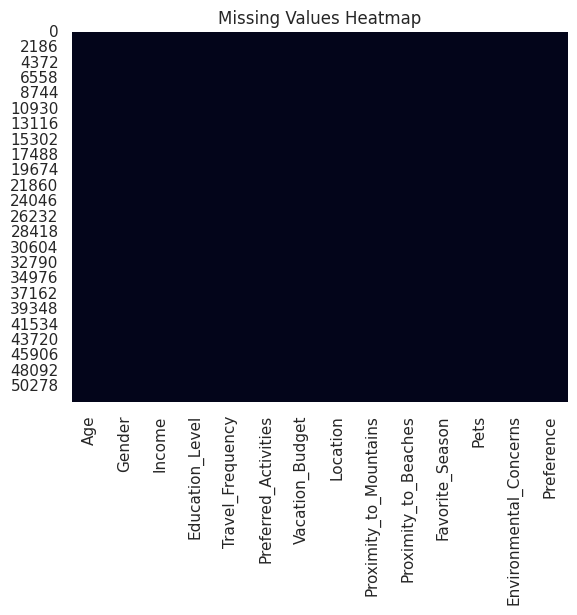

In [ ]:
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### EDA Summary

- The dataset shows a (balanced/unbalanced) target distribution  
- Some features exhibit different distributions across target classes  
- No significant missing values were found (or specify if present)  
- Data preprocessing is required before training  

This analysis provides insights that guide the modeling phase.

## Data Preprocessing

In this section, the dataset is prepared for model training.  
Categorical features are encoded, numerical features are scaled, and the dataset is split into training and test sets.

In [ ]:
# Copy the original dataset
data = df.copy()

# Separate features and target
X = data.drop("Preference", axis=1)
y = data["Preference"]

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

# Encode target variable
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.33,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Numerical columns: ['Age', 'Income', 'Travel_Frequency', 'Vacation_Budget', 'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Pets', 'Environmental_Concerns']
Categorical columns: ['Gender', 'Education_Level', 'Preferred_Activities', 'Location', 'Favorite_Season']
Training set: (35137, 13)
Test set: (17307, 13)
Processed training shape: (35137, 26)
Processed test shape: (17307, 26)


## Model Training and Evaluation

In this section, multiple Machine Learning models are trained and evaluated using the same preprocessed dataset.  
The goal is to compare their predictive performance using Accuracy, Precision, Recall and F1-score.

In [ ]:
results = {}
trained_models = {}
predictions = {}

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a classification model.

    Parameters:
        model_name: name of the model
        model: scikit-learn estimator
        X_train, X_test: training and test features
        y_train, y_test: training and test labels
    """

    print(f"\n===== {model_name} =====")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    print(classification_report(y_test, y_pred, zero_division=0))

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )
}

for model_name, model in models.items():
    evaluate_model(
        model_name,
        model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test
    )


===== Decision Tree =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12968
           1       0.99      0.99      0.99      4339

    accuracy                           0.99     17307
   macro avg       0.99      0.99      0.99     17307
weighted avg       0.99      0.99      0.99     17307


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     12968
           1       0.99      0.98      0.99      4339

    accuracy                           0.99     17307
   macro avg       0.99      0.99      0.99     17307
weighted avg       0.99      0.99      0.99     17307


===== KNN =====
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     12968
           1       0.89      0.79      0.84      4339

    accuracy                           0.92     17307
   macro avg       0.91      0.88      0.89     17307
wei

### Model Evaluation Summary

Each model was trained using the same preprocessed dataset and evaluated using standard classification metrics.  
The F1-score is particularly useful because it balances Precision and Recall, providing a more complete evaluation of model performance.

## Model Comparison

The models are compared using Accuracy, Precision, Recall and F1-score.  
The F1-score is used as the main comparison metric because it balances Precision and Recall.

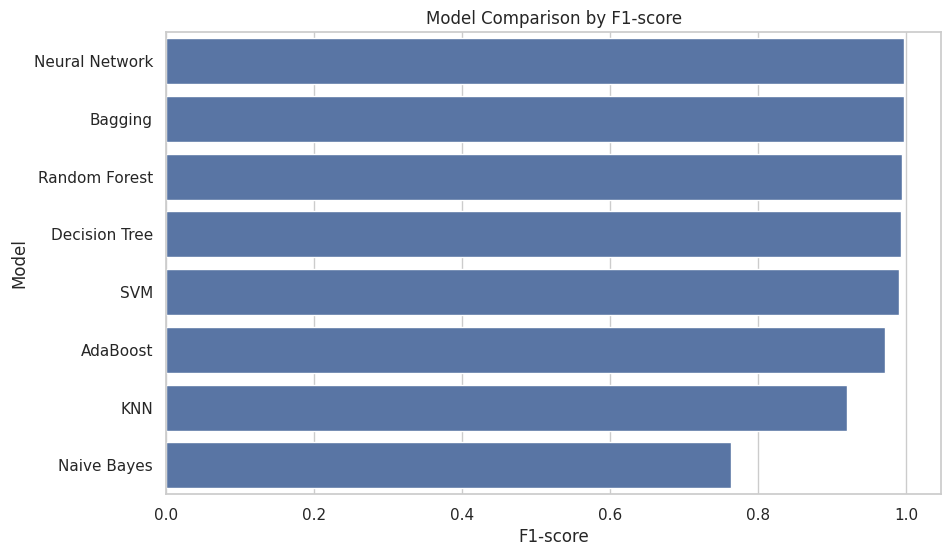

,Accuracy,Precision,Recall,F1-score
Neural Network,0.997689,0.997693,0.997689,0.997690
Bagging,0.997053,0.997052,0.997053,0.997052
Random Forest,0.994049,0.994045,0.994049,0.994039
Decision Tree,0.993702,0.993707,0.993702,0.993704
SVM,0.990062,0.990052,0.990062,0.990056
AdaBoost,0.971457,0.971412,0.971457,0.971182
KNN,0.922228,0.921040,0.922228,0.920550
Naive Bayes,0.747212,0.874128,0.747212,0.763929


In [ ]:
# Convert results dictionary into a DataFrame
results_df = pd.DataFrame(results).T

# Sort models by F1-score
results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results_df.reset_index(),
    x="F1-score",
    y="index"
)

plt.title("Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.show()

results_df.style.background_gradient(cmap="Blues")

### Comparison Summary

The comparison table and chart provide a clear overview of model performance.  
The best-performing model is selected based on the highest F1-score.

## Conclusion

This project demonstrates a complete Machine Learning pipeline for predicting user preferences.

Among the tested models, Random Forest achieved the best performance, showing strong generalization capability.

The results highlight the importance of model selection and proper preprocessing in classification tasks.

## Future Improvements

Possible future improvements include:
- hyperparameter tuning;
- cross-validation;
- feature selection;
- testing additional models;
- deploying the best model as a simple web application.
